In [1]:
# MeanShift 평균을 찍으면서 이동함 > cluster의 갯수가 바뀔 수 있음
# K를 정하지 않아도 자동으로 생성 (K를 정함에 있어서의 문제를 해결해줌, 신경 쓸 부분이 적어짐)

In [2]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples = 200,
                  n_features = 2,
                  centers = 3,
                  cluster_std = 0.7,
                  random_state = 42)

meanshift = MeanShift(bandwidth = 0.8) # MeanShift의 핵심 하이퍼파라미터
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2 3 4 5 6 7]


In [3]:
meanshift = MeanShift(bandwidth = 1.0)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2 3 4]


In [4]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print(round(bandwidth, 3))

1.877


In [5]:
import pandas as pd

df = pd.DataFrame(data = X, columns = ["ftr1", "ftr2"])
df["target"] = y

best_bandwidth = estimate_bandwidth(X) # X값만 가지고 estimate

meanshift = MeanShift(bandwidth = best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print(np.unique(cluster_labels))

[0 1 2]


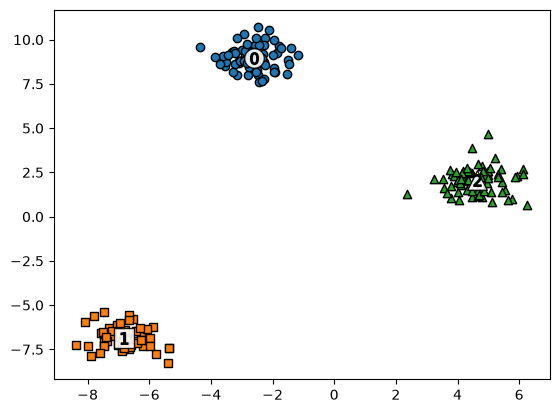

In [6]:
import matplotlib.pyplot as plt

df["meanshift_label"] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)

markers = ["o", "s", "^", "x", "*"]

for label in unique_labels:
    label_cluster = df[df["meanshift_label"] == label]
    center = centers[label]

    plt.scatter(
        x = label_cluster["ftr1"], 
        y = label_cluster["ftr2"], 
        edgecolor = "k",
        marker = markers[label])

    plt.scatter(
        x = center[0],
        y = center[1],
        s = 200,
        color = "white",
        alpha = 0.9,
        edgecolor = "k",
        marker = markers[label])

    plt.scatter(
            x = center[0],
            y = center[1],
            s = 70,
            color = "k",
            edgecolor = "k",
            marker = "$%d$" % label)

plt.show()

In [7]:
print(df.groupby("target")["meanshift_label"].value_counts())

target  meanshift_label
0       0                  67
1       2                  67
2       1                  66
Name: count, dtype: int64
